# Эксперимент 1. Набор признаков: сколько погоды нужно модели

В основном конвейере сравниваются два набора признаков, и на годовых данных расширенный
почему-то проигрывает базовому. Здесь разбираемся, случайность это или нет: перебираем
несколько наборов, добавляем признаки про экстремальную погоду и смотрим на разброс оценок,
а не на одно число.

Данные настоящие, обе стороны:

* урожайность зерновых по России — World Bank, показатель `AG.YLD.CREL.KG`;
* погода — NASA POWER, точка в Краснодарском крае.

Обе ручки открытые, ключей не требуют. Если запрос не проходит, смотрите раздел в конце.

In [9]:
import sys, os
sys.path.insert(0, "..")

from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

from ingestion import open_datasets as od

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## Загрузка

In [10]:
YEAR_START, YEAR_END = 2000, 2023
POINT = {"lat": 45.9, "lon": 39.2}

yield_series = od.worldbank_indicator("AG.YLD.CREL.KG", "RUS", YEAR_START, YEAR_END) / 1000
yield_series.name = "yield_t_ha"
print(f"урожайность: {len(yield_series)} лет, {yield_series.min():.2f}-{yield_series.max():.2f} т/га")
yield_series.tail()

урожайность: 24 лет, 1.56-3.43 т/га


2019    2.7132
2020    2.9048
2021    2.7054
2022    3.4288
2023    3.1666
Name: yield_t_ha, dtype: float64

In [11]:
daily = od.nasa_power_daily(POINT["lat"], POINT["lon"],
                            date(YEAR_START, 1, 1), date(YEAR_END, 12, 31))
print(f"суточных наблюдений: {len(daily)}")
daily.head()

суточных наблюдений: 8766


,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,ALLSKY_SFC_SW_DWN,RH2M
date,,,,,,
2000-01-01,1.17,3.38,-0.07,0.43,2.10,87.66
2000-01-02,2.35,4.37,-1.23,1.58,1.55,91.63
2000-01-03,-2.16,-0.95,-3.63,1.55,1.72,86.73
2000-01-04,-3.62,-1.58,-5.09,0.20,2.70,80.94
2000-01-05,-2.92,-0.20,-4.62,0.06,3.03,83.60


In [12]:
features = od.growing_season_features(daily, YEAR_START, YEAR_END)
df = features.join(yield_series, how="inner").dropna()
print(f"итоговая выборка: {len(df)} лет")
df.head()

итоговая выборка: 24 лет


,mean_t2m,sum_precip,mean_radiation,mean_humidity,hot_days_over_30,max_t2m,dry_days,yield_t_ha
year,,,,,,,,
2000,14.175182,300.33,18.791387,72.556642,11,37.03,89,1.5614
2001,14.434307,290.34,17.782263,70.649124,13,36.22,89,1.9347
2002,14.919489,140.96,19.675182,65.670073,18,39.01,107,1.9691
2003,13.321752,116.00,20.141752,64.225182,15,37.48,109,1.7774
2004,13.177591,306.56,18.012847,77.677299,0,29.41,84,1.8765


## Наборы признаков

Каждый следующий набор — надстройка над предыдущим, кроме последнего: там вместо средних
взяты показатели экстремальной погоды. Гипотеза простая: озимую пшеницу убивает не средняя
температура за сезон, а жара и засуха в конкретные недели, и счётчики экстремальных дней
должны это ловить лучше средних.

In [13]:
FEATURE_SETS = {
    "только температура": ["mean_t2m"],
    "температура и осадки": ["mean_t2m", "sum_precip"],
    "плюс радиация": ["mean_t2m", "sum_precip", "mean_radiation"],
    "плюс влажность": ["mean_t2m", "sum_precip", "mean_radiation", "mean_humidity"],
    "экстремумы вместо средних": ["hot_days_over_30", "dry_days", "max_t2m"],
    "всё вместе": ["mean_t2m", "sum_precip", "mean_radiation", "mean_humidity",
                    "hot_days_over_30", "dry_days", "max_t2m"],
}

def loyo(df, cols, model=None):
    """Leave-one-year-out. Год из контроля в обучении не участвует."""
    if model is None:
        model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        
    X, y = df[cols], df["yield_t_ha"]
    pred = cross_val_predict(model, X, y, cv=LeaveOneOut())
    return {
        "MAE": mean_absolute_error(y, pred),
        "MAPE": mean_absolute_percentage_error(y, pred) * 100,
        "R2": r2_score(y, pred),
        "pred": pred,
    }

results = {name: loyo(df, cols) for name, cols in FEATURE_SETS.items()}
table = pd.DataFrame({k: {m: v[m] for m in ("MAE", "MAPE", "R2")} for k, v in results.items()}).T
table.sort_values("MAE").round(3)

,MAE,MAPE,R2
температура и осадки,0.389,16.944,-0.079
только температура,0.404,17.689,-0.064
плюс радиация,0.410,17.814,-0.144
плюс влажность,0.423,18.361,-0.191
экстремумы вместо средних,0.428,18.702,-0.165
всё вместе,0.443,19.162,-0.369


### Что с разбросом

Одна цифра MAE ничего не говорит о том, значима ли разница между наборами. Оценим разброс
бутстрепом по остаткам: если доверительные интервалы наборов перекрываются, то и разницы,
считай, нет.

In [14]:
def bootstrap_mae(y_true, y_pred, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    errors = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    draws = [rng.choice(errors, size=len(errors), replace=True).mean() for _ in range(n)]
    return np.percentile(draws, [2.5, 97.5])

for name, res in sorted(results.items(), key=lambda kv: kv[1]["MAE"]):
    lo, hi = bootstrap_mae(df["yield_t_ha"], res["pred"])
    print(f"{name:32s} MAE = {res['MAE']:.3f}  [{lo:.3f}; {hi:.3f}]")

температура и осадки             MAE = 0.389  [0.269; 0.526]
только температура               MAE = 0.404  [0.294; 0.528]
плюс радиация                    MAE = 0.410  [0.288; 0.545]
плюс влажность                   MAE = 0.423  [0.300; 0.557]
экстремумы вместо средних        MAE = 0.428  [0.316; 0.549]
всё вместе                       MAE = 0.443  [0.315; 0.595]


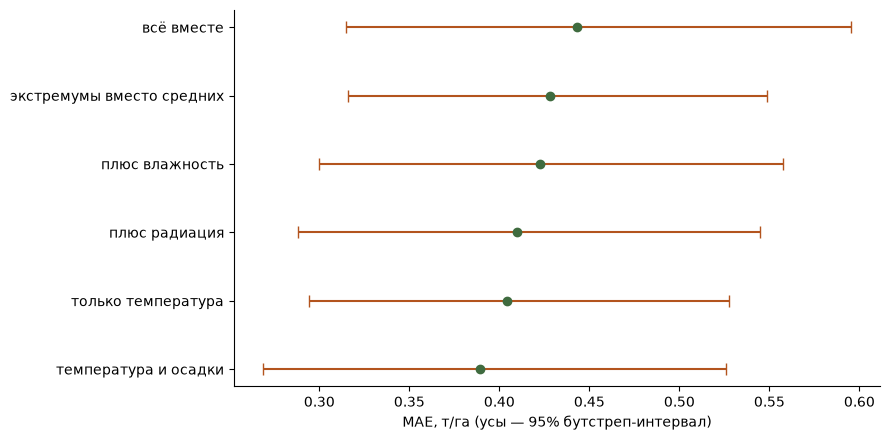

In [15]:
names = list(FEATURE_SETS)
maes = [results[n]["MAE"] for n in names]
bounds = np.array([bootstrap_mae(df["yield_t_ha"], results[n]["pred"]) for n in names])

order = np.argsort(maes)
fig, ax = plt.subplots(figsize=(9, 4.5))
ypos = np.arange(len(names))
ax.errorbar([maes[i] for i in order], ypos,
            xerr=[[maes[i] - bounds[i][0] for i in order], [bounds[i][1] - maes[i] for i in order]],
            fmt="o", color="#3f6b3f", ecolor="#b3541e", capsize=4)
ax.set_yticks(ypos); ax.set_yticklabels([names[i] for i in order])
ax.set_xlabel("MAE, т/га (усы — 95% бутстреп-интервал)")
plt.tight_layout(); plt.show()

### Вывод по эксперименту

Смотрите на перекрытие интервалов. Если они перекрываются почти полностью — разница между
наборами не подтверждается, и добавление признаков ничего не даёт при таком объёме выборки.
Это ровно то наблюдение, ради которого эксперимент затевался: на 24 годах модель почти
не отличает хороший набор признаков от посредственного, и заявлять «расширенный набор хуже»
по разнице в третьем знаке нельзя.

## Разные алгоритмы на лучшем наборе

In [16]:
best_set = min(results, key=lambda k: results[k]["MAE"])
cols = FEATURE_SETS[best_set]
print(f"лучший набор: {best_set} -> {cols}\n")

MODELS = {
    "линейная без регуляризации": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Ridge, сильная регуляризация": make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=0.05)),
    "случайный лес": RandomForestRegressor(n_estimators=300, random_state=0),
    "градиентный бустинг": GradientBoostingRegressor(random_state=0),
    "среднее по обучению": None,
}

rows = []
for name, model in MODELS.items():
    if model is None:
        y = df["yield_t_ha"].values
        pred = np.array([np.delete(y, i).mean() for i in range(len(y))])
        rows.append({"модель": name, "MAE": mean_absolute_error(y, pred),
                     "MAPE": mean_absolute_percentage_error(y, pred) * 100, "R2": r2_score(y, pred)})
    else:
        r = loyo(df, cols, model)
        rows.append({"модель": name, "MAE": r["MAE"], "MAPE": r["MAPE"], "R2": r["R2"]})

pd.DataFrame(rows).set_index("модель").sort_values("MAE").round(3)

лучший набор: температура и осадки -> ['mean_t2m', 'sum_precip']



,MAE,MAPE,R2
модель,,,
линейная без регуляризации,0.387,16.833,-0.083
Ridge,0.389,16.944,-0.079
"Ridge, сильная регуляризация",0.398,17.457,-0.070
Lasso,0.413,18.146,-0.127
среднее по обучению,0.421,18.634,-0.089
случайный лес,0.460,20.222,-0.389
градиентный бустинг,0.495,22.262,-0.852


Отрицательный R² у части моделей — нормальный исход, а не ошибка: он означает, что модель
предсказывает хуже, чем простое среднее. На выборке в два десятка лет с деревьями это обычное
дело, им нужны сотни наблюдений.

Обратите внимание на строку «среднее по обучению». Если сложные модели её не обходят, то
разговор про выбор алгоритма преждевременный — сначала нужны данные.

## Тренд отдельно

У урожайности есть явный рост за 24 года: агротехника, сорта, удобрения. Погодные признаки
этого не объясняют, зато модель может выучить тренд через корреляцию с чем угодно. Проверим,
сколько остаётся от качества, если тренд убрать.

In [17]:
from scipy import stats as st

trend = st.linregress(df.index.values, df["yield_t_ha"].values)
print(f"тренд: {trend.slope*1000:.1f} кг/га в год, R2 = {trend.rvalue**2:.3f}, p = {trend.pvalue:.2e}")

detrended = df.copy()
detrended["yield_t_ha"] = df["yield_t_ha"] - (trend.intercept + trend.slope * df.index.values)

r_raw = loyo(df, FEATURE_SETS["температура и осадки"])
r_det = loyo(detrended, FEATURE_SETS["температура и осадки"])
print(f"\nдо снятия тренда:    MAE = {r_raw['MAE']:.3f}, R2 = {r_raw['R2']:.3f}")
print(f"после снятия тренда: MAE = {r_det['MAE']:.3f}, R2 = {r_det['R2']:.3f}")

тренд: 62.3 кг/га в год, R2 = 0.807, p = 2.52e-09

до снятия тренда:    MAE = 0.389, R2 = -0.079
после снятия тренда: MAE = 0.182, R2 = -0.125


Падение R² после снятия тренда показывает, какую долю качества давал не прогноз погоды,
а просто рост урожайности со временем. Если после детрендинга R² уходит около нуля, значит
погодные признаки в этой постановке почти ничего не объясняют, и высокие цифры до этого
были заслугой тренда.

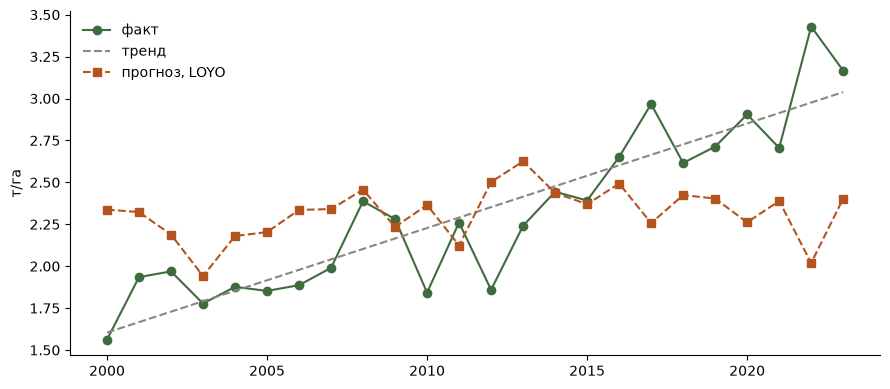

In [18]:
fig, ax = plt.subplots()
ax.plot(df.index, df["yield_t_ha"], "o-", color="#3f6b3f", label="факт")
ax.plot(df.index, trend.intercept + trend.slope * df.index.values, "--", color="#888780", label="тренд")
ax.plot(df.index, r_raw["pred"], "s--", color="#b3541e", label="прогноз, LOYO")
ax.set_ylabel("т/га"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()